In [ ]:
import torch
import matplotlib.pyplot as plt
import numpy as np
# from ultralytics import YOLO

# =============================
# Load YOLOv8 Detector
# =============================
model = YOLO("yolov8n.pt")  # detector

# =============================
# Hook Feature Map (conv layers)
# =============================
target_layers = [0, 2, 4]  # conv layers index
feature_maps = {}

def hook_fmap(module, input, output):
    feature_maps[module] = output.detach()

for i, layer in enumerate(model.model.model):
    if i in target_layers:
        layer.register_forward_hook(hook_fmap)

# =============================
# Hook Dense-like Activation (2 layers)
# =============================
# เลือก conv layer ก่อน head 2 layer
dense_like_layers = [model.model.model[-3], model.model.model[-2]]  # workaround
dense_activations = {}

def hook_dense(module, input, output):
    dense_activations[module] = output.detach()

for layer in dense_like_layers:
    layer.register_forward_hook(hook_dense)

# =============================
# Images
# =============================
image_paths = ["1.JPG", "2.JPG", "3.JPG", "4.JPG", "5.JPG"]

for img_path in image_paths:
    feature_maps.clear()
    dense_activations.clear()

    results = model(img_path)

    # =============================
    # Feature Map Heatmaps
    # =============================
    num_layers = len(feature_maps)
    fig, axes = plt.subplots(1, num_layers, figsize=(5*num_layers, 5))
    if num_layers == 1:
        axes = [axes]

    for ax, (layer, fmap) in zip(axes, feature_maps.items()):
        fmap = fmap[0]  # batch=0
        fmap_np = fmap.cpu().numpy()
        mean_map = np.mean(fmap_np, axis=0)
        ax.imshow(mean_map, cmap='hot')
        ax.set_title(f"Feature Map: Layer {layer}")
        ax.axis('off')
    plt.suptitle(f"Feature Maps - {img_path}")
    plt.show()

    # =============================
    # Dense-like Activation (2 layers)
    # =============================
    for idx, (layer, act) in enumerate(dense_activations.items(), 1):
        act_flat = act[0].cpu().numpy().flatten()
        plt.figure(figsize=(12,4))
        plt.bar(range(len(act_flat)), act_flat)
        plt.xlabel("Neuron / Feature Index")
        plt.ylabel("Activation")
        plt.title(f"Dense-like Activation Layer {idx} - {layer}")
        plt.show()

AttributeError: 'FasterRCNN' object has no attribute 'model'

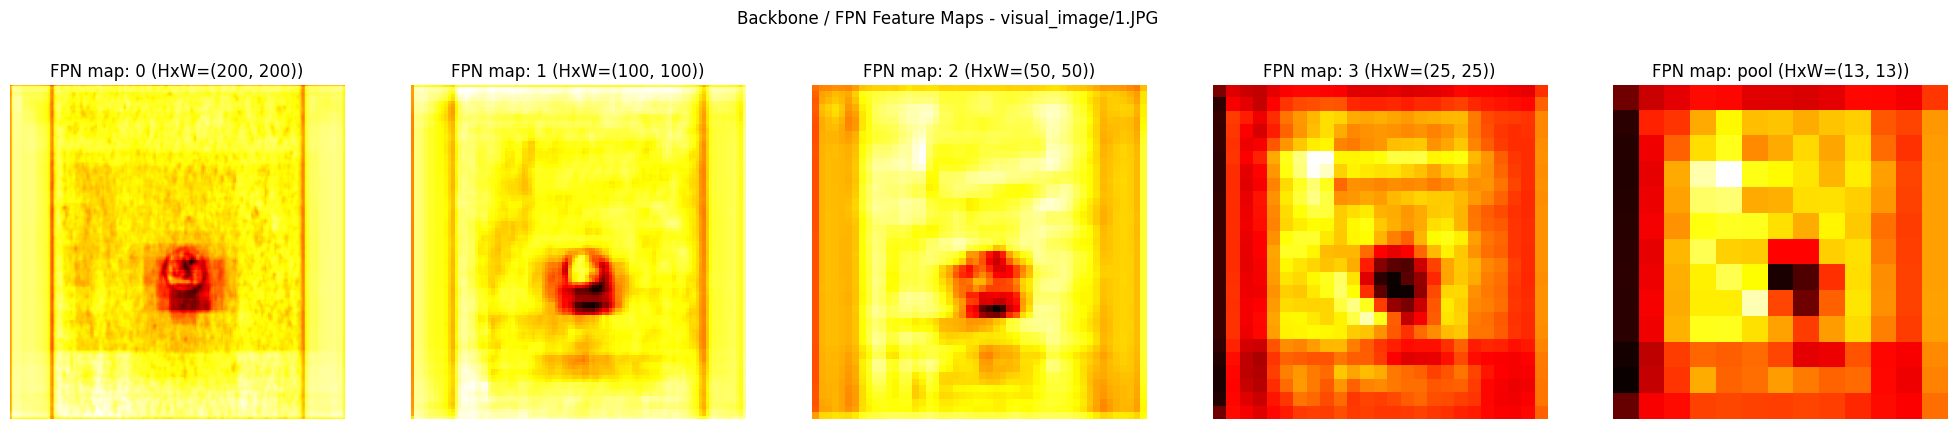

finish Desne-like Activation


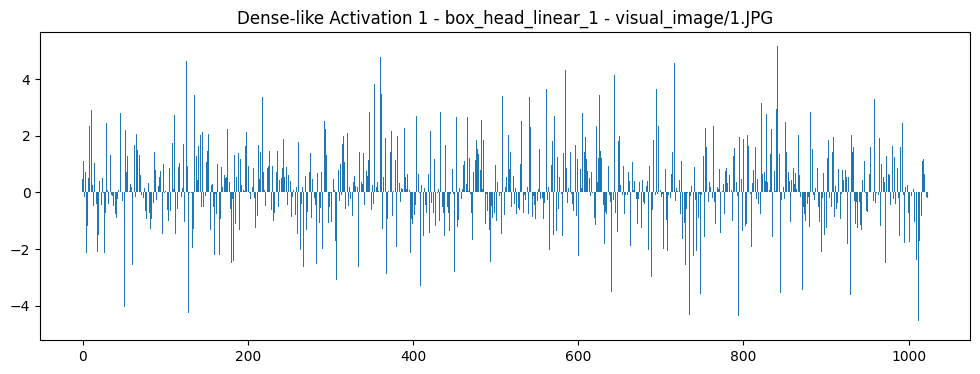

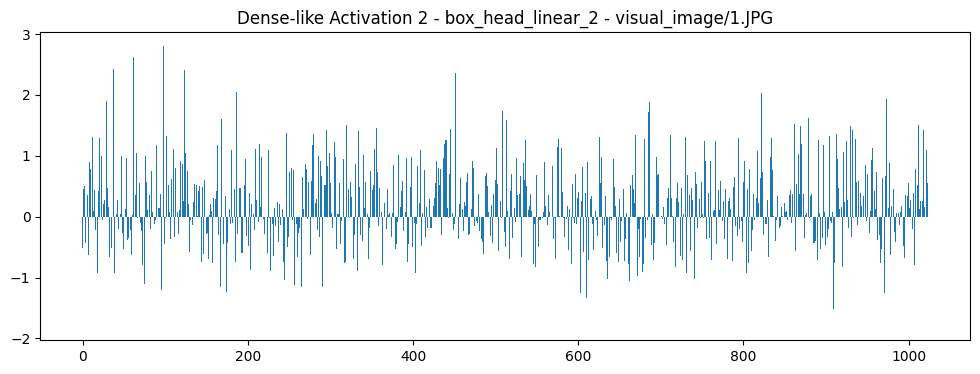

finish feature map


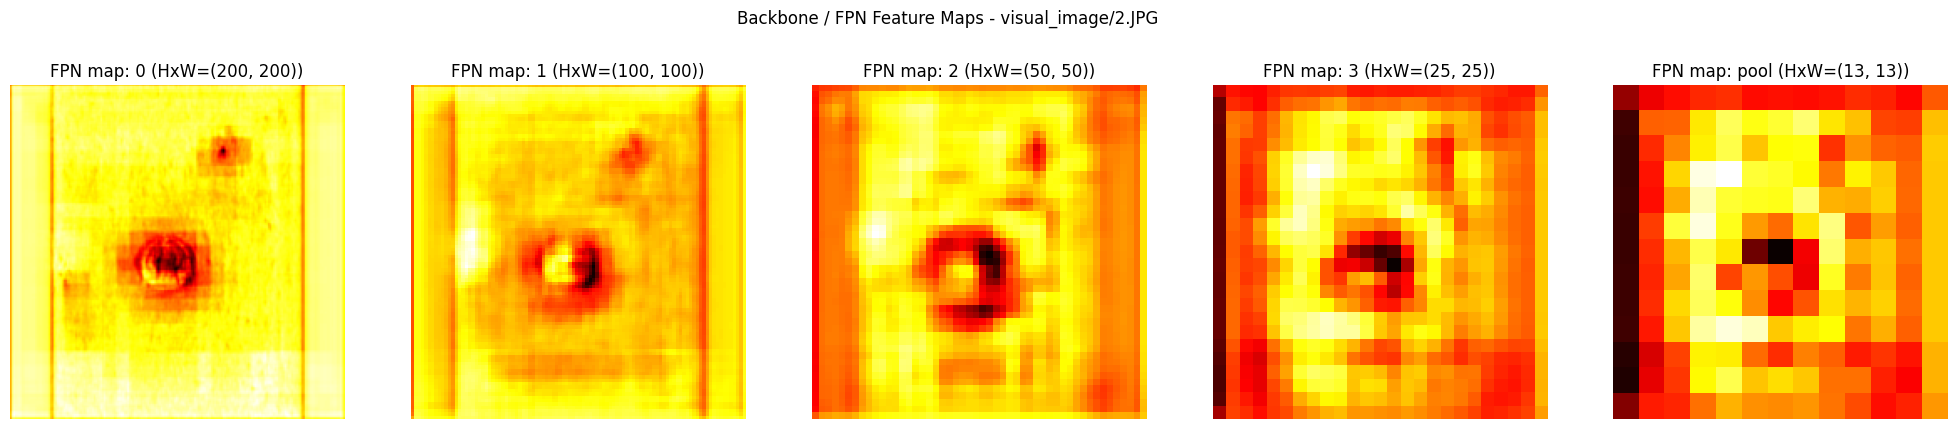

finish Desne-like Activation


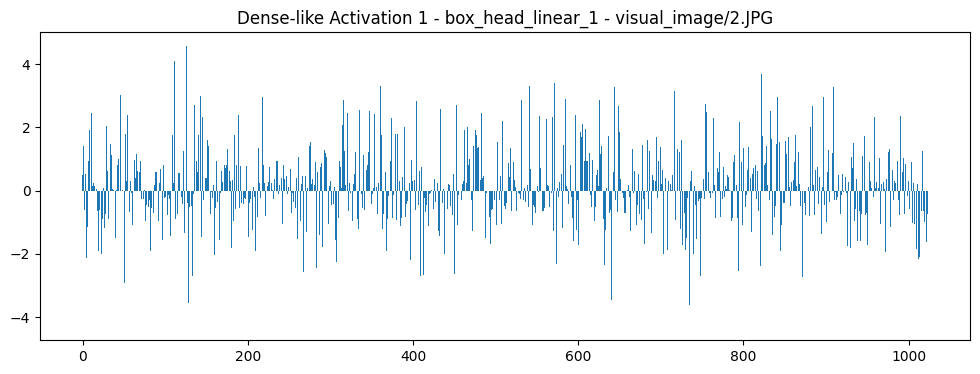

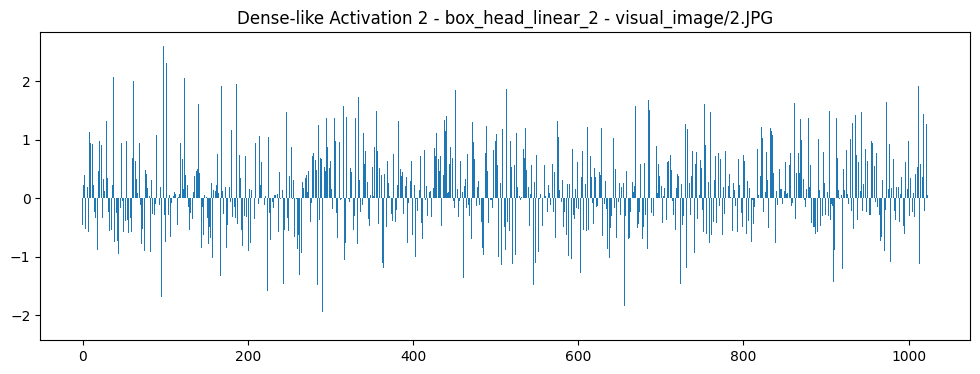

finish feature map


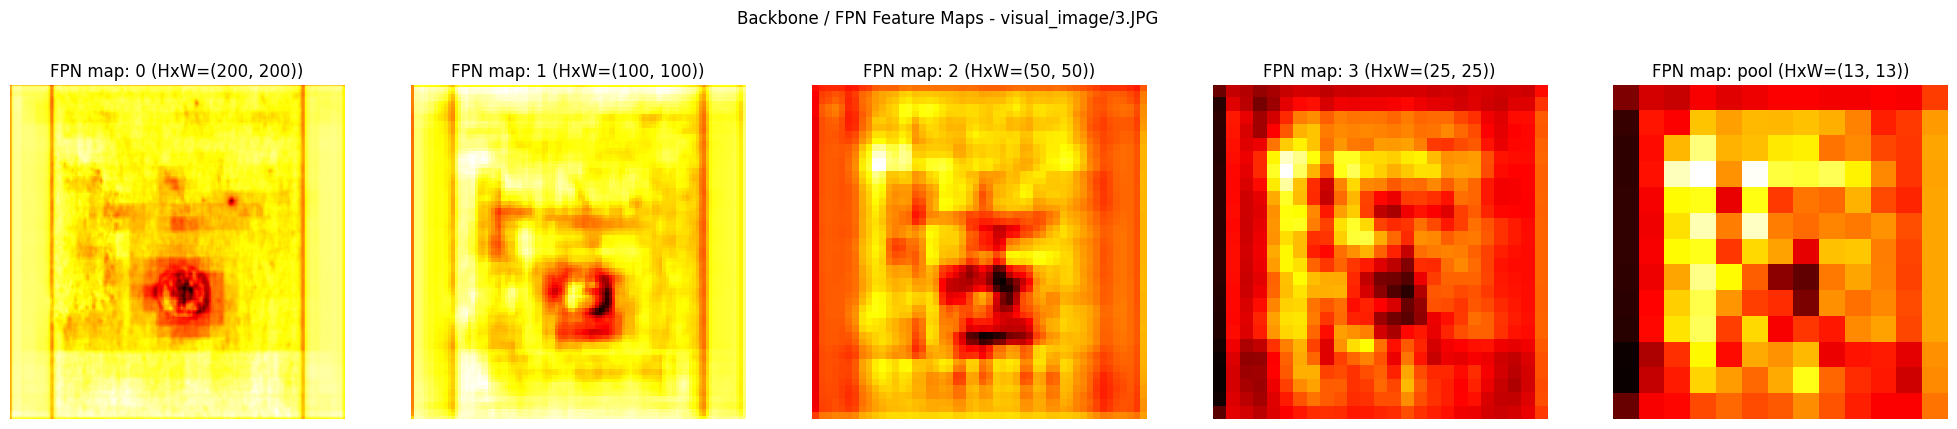

finish Desne-like Activation


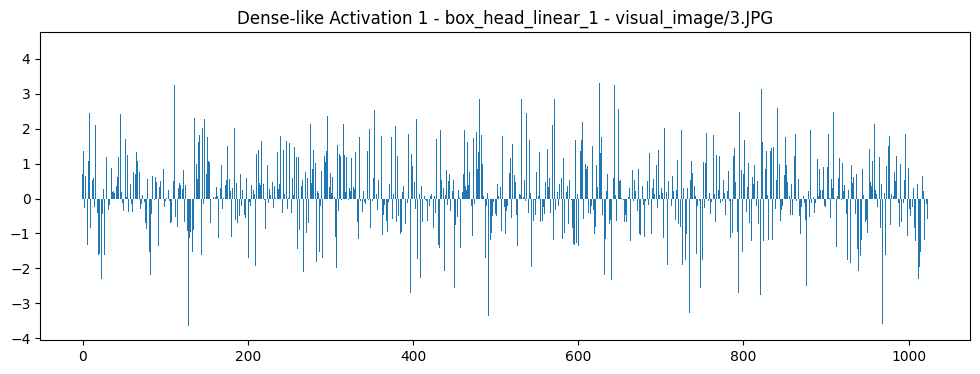

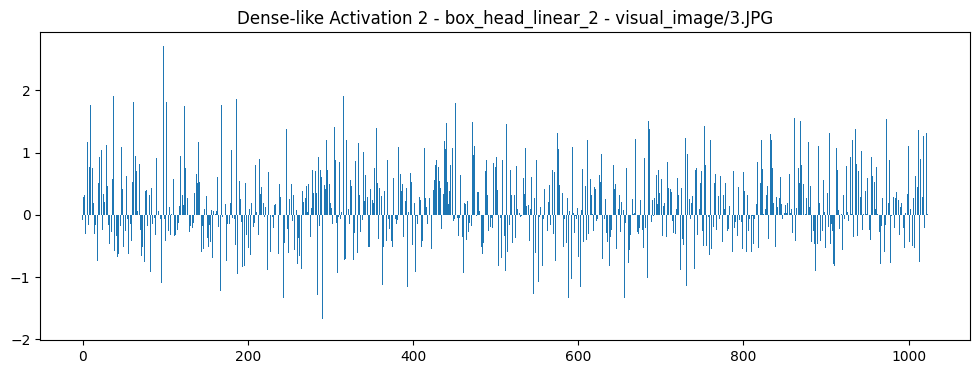

finish feature map


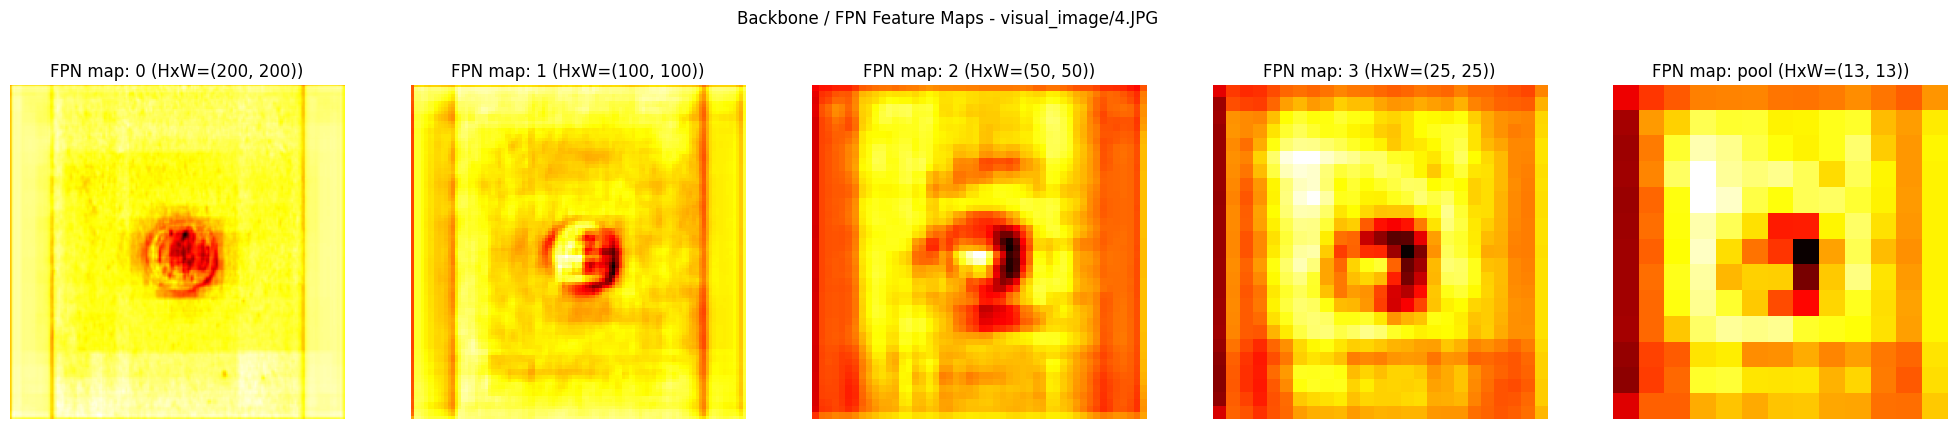

finish Desne-like Activation


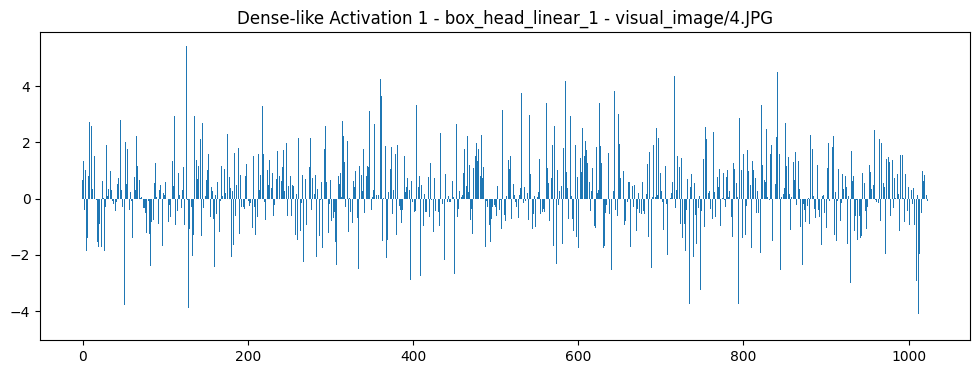

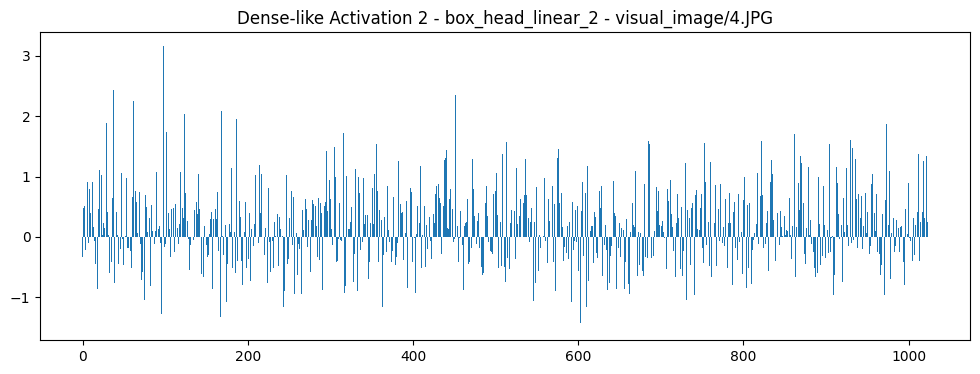

finish feature map


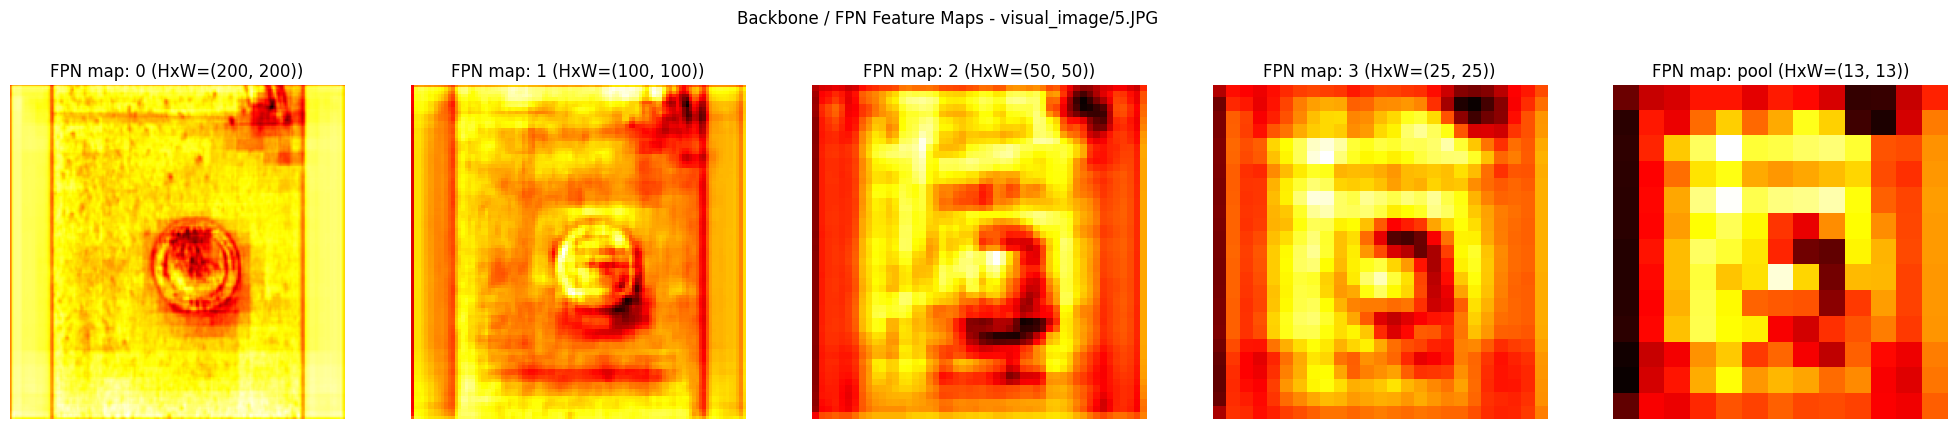

finish Desne-like Activation


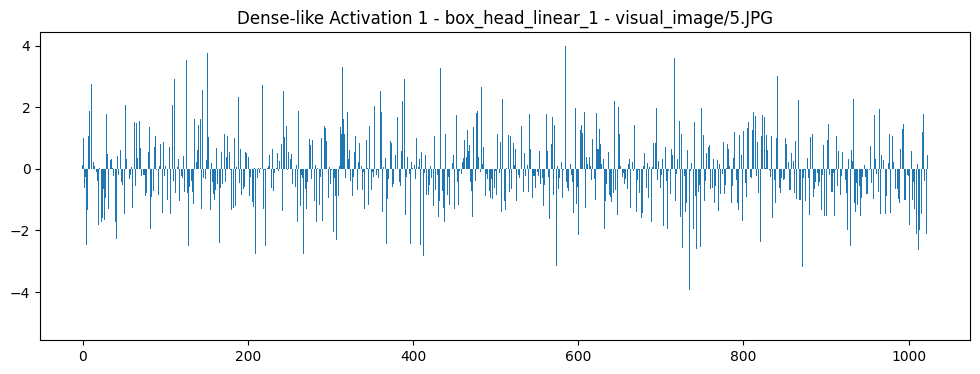

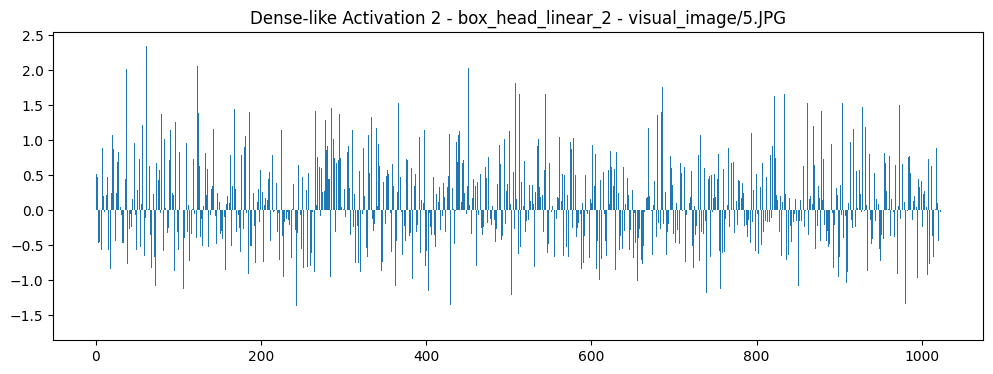

finish feature map


In [2]:
import torch
import torchvision
from torchvision.models.detection import fasterrcnn_resnet50_fpn
from torchvision.transforms import functional as F
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image

# Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# =============================
# Load Faster R-CNN (backbone=ResNet50-FPN)
# =============================
model = fasterrcnn_resnet50_fpn(pretrained=True, progress=True)
model.to(device)
model.eval()

# =============================
# Hook Feature Maps (FPN outputs)
# =============================
# backbone returns an OrderedDict of feature maps (e.g., {"0":..., "1":..., ...})
feature_maps = {}

def hook_backbone(module, input, output):
    # output is an OrderedDict of feature maps (tensors)
    # copy and detach to CPU to avoid GPU mem hold when plotting later
    feature_maps.clear()
    for k, v in output.items():
        feature_maps[k] = v.detach().cpu()

# register on the backbone (BackboneWithFPN)
model.backbone.register_forward_hook(hook_backbone)

# =============================
# Hook Dense-like Activation (ROI box_head)
# =============================
# The default box_head in torchvision Faster R-CNN is a TwoMLPHead containing two Linear layers.
# We'll find the first two Linear modules inside model.roi_heads.box_head and hook them.
dense_activations = {}
dense_layers = []

# Search for torch.nn.Linear modules inside box_head and register hooks on the first two found
for module in model.roi_heads.box_head.modules():
    if isinstance(module, torch.nn.Linear):
        dense_layers.append(module)
    if len(dense_layers) >= 2:
        break

def make_dense_hook(name):
    def hook(module, input, output):
        # output: tensor of shape (num_rois, hidden_dim) typically
        dense_activations[name] = output.detach().cpu()
    return hook

for i, layer in enumerate(dense_layers):
    layer.register_forward_hook(make_dense_hook(f"box_head_linear_{i+1}"))

# =============================
# Image preprocessing helper
# =============================
def load_image_as_tensor(path, device):
    img = Image.open(path).convert("RGB")
    # Faster-RCNN expects tensor in 0-1 range, CxHxW
    t = F.to_tensor(img).to(device)
    return t, img

# =============================
# Run inference and visualize
# =============================
image_paths = ["visual_image/1.JPG", "visual_image/2.JPG", "visual_image/3.JPG", "visual_image/4.JPG", "visual_image/5.JPG"]  # ปรับตามไฟล์จริง

for img_path in image_paths:
    feature_maps.clear()
    dense_activations.clear()

    img_tensor, pil_img = load_image_as_tensor(img_path, device)
    # model expects a list of tensors
    with torch.no_grad():
        outputs = model([img_tensor])

    # =============================
    # Feature Map Heatmaps (from FPN)
    # =============================
    if len(feature_maps) == 0:
        print(f"[Warning] No feature maps captured for {img_path}.")
    else:
        # feature_maps is an OrderedDict-like but keys are strings like "0","1","2","3"
        layers_items = list(feature_maps.items())
        num_layers = len(layers_items)
        fig, axes = plt.subplots(1, num_layers, figsize=(5 * num_layers, 5))
        if num_layers == 1:
            axes = [axes]

        for ax, (k, fmap) in zip(axes, layers_items):
            # fmap shape: (B, C, H, W)  -> take first batch
            fmap0 = fmap[0].numpy()
            mean_map = np.mean(fmap0, axis=0)  # average across channels -> HxW
            ax.imshow(mean_map, cmap="hot")
            ax.set_title(f"FPN map: {k} (HxW={mean_map.shape})")
            ax.axis("off")
        plt.suptitle(f"Backbone / FPN Feature Maps - {img_path}")
        plt.show()
    
    print("finish Desne-like Activation")

    # =============================
    # Dense-like Activation (box_head linear layers)
    # =============================
    if len(dense_activations) == 0:
        print(f"[Warning] No dense activations captured for {img_path}.")
    else:
        for idx, (name, act) in enumerate(dense_activations.items(), 1):
            # act shape typically: (num_rois, hidden_dim)
            # act_flat = act.cpu().numpy().flatten()

            act_mean = act.mean(dim=0).cpu().numpy()  # shape (hidden_dim,)
            plt.figure(figsize=(12,4))
            plt.bar(range(len(act_mean)), act_mean)
            plt.title(f"Dense-like Activation {idx} - {name} - {img_path}")
            plt.show()
            
            # plt.figure(figsize=(12, 4))
            # plt.bar(range(len(act_flat)), act_flat)
            # plt.xlabel("Neuron / Feature Index")
            # plt.ylabel("Activation")
            # plt.title(f"Dense-like Activation {idx} - {name} - {img_path}")
            # plt.show()
    
    print("finish feature map")

    # ====================


In [5]:
list(dense_activations)

['box_head_linear_1', 'box_head_linear_2']